# DATASET TITLE: **BIHAR ASSEMBLY ELECTION RESULTS 2020: WINNER PREDICTION**

#### NAME: **Divyanshu Goyal**
#### SECTION: **CSE - II** 
#### ENROLLMENT NUMBER : **240454**
#### COURSE : **Data analytics using python** 
#### Course Code: **DAP1101**
#### Institution: **BML MUNJAL UNIVERSITY** 
#### Date of Submission: **18 November 2025**

#### ABOUT PROJECT :
##### This mini project involves a rigorous analysis of the 2020 Bihar Legislative Assembly Election results. The core objective is to apply data science methods to understand the distribution of electoral power and predict the outcome for individual candidates.
##### **Objectives:**
1. **Data Structuring:** Engineer a robust binary **Target Variable** (`Winner` status) by identifying the top vote-getter in each constituency.
2. **Statistical Inference:** Employ **Chi-Square Test** to assess the statistical dependency between a candidate's political party and their eventual winning status.
3. **Predictive Modeling:** Build a **Classification Model (K-Nearest Neighbors)** to predict whether a candidate will win or lose based on their vote share and party affiliation.

Dataset - Bihar_election_results.csv https://www.kaggle.com/datasets/etqadahmadkhan/bihar-polls-2025

## Step 1: Problem Definition & Dataset Selection

**Dataset Source:** Bihar Election Results 2020 (`bihar_election_results.csv`)

**Description:**
- **Scope:** Contains raw results for all candidates across 243 constituencies.
- **Features:** 
 - **Contextual:** `Constituency Number`, `Constituency Name`, `Candidate Name`.
 - **Electoral:** `Party`, `EVM Votes`, `Postal Votes`, `Total Votes`, `Vote Percentage`.
- **Target Variable (Engineered):** `Winner` (Binary: 1 for winner, 0 for loser) — This is a **Classification Problem**.

In [10]:
# Core Data & ML Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Visualization Configuration
sns.set_theme(style="whitegrid")
plt.style.use('fivethirtyeight')

In [11]:
# Data Ingestion
try:
 df = pd.read_csv('bihar_election_results.csv')
 print("Dataset loaded successfully.")
 print(f"Initial Dimensions: {df.shape}")
except FileNotFoundError:
 print("Error: CSV file not found. Please upload 'bihar_election_results.csv'.")

# Preview structure and types
df.info()

Dataset loaded successfully.
Initial Dimensions: (2859, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Constituency Number  2859 non-null   int64  
 1   Constituency Name    2859 non-null   object 
 2   Serial Number        2859 non-null   int64  
 3   Candidate Name       2859 non-null   object 
 4   Party                2859 non-null   object 
 5   EVM Votes            2859 non-null   int64  
 6   Postal Votes         2859 non-null   int64  
 7   Total Votes          2859 non-null   int64  
 8   Vote Percentage      2859 non-null   float64
dtypes: float64(1), int64(5), object(3)
memory usage: 201.2+ KB


## Step 2: Data Cleaning & Preparation

**Preprocessing Logic & Justification:**
1. **Target Variable Engineering:** The dataset lacks a direct winner column. We define the **Winner** as the candidate with the maximum `Total Votes` within each `Constituency Name`.
2. **Party Consolidation:** The `Party` column contains a large number of unique values. For statistical stability, we will group all minor parties into an 'Other' category, focusing the analysis on the major national and regional players.
3. **Irrelevant Column Removal:** `Serial Number`, `EVM Votes`, and `Postal Votes` are aggregated in `Total Votes`, and `Candidate Name` is unique, so these are dropped to simplify the model.

In [12]:
# 1. Target Variable Engineering: Identifying the Winner per Constituency
# Find the index of the row with the maximum Total Votes for each Constituency
winner_indices = df.groupby('Constituency Name')['Total Votes'].idxmax()

# Initialize 'Winner' column to 0 (Loser)
df['Winner'] = 0

# Set the rows corresponding to winner_indices to 1 (Winner)
df.loc[winner_indices, 'Winner'] = 1

print(f"Target Variable Engineered. Winners Count: {df['Winner'].sum()}")

# 2. Party Consolidation
# Identify parties that appear at least 50 times (threshold for major/relevant party)
party_counts = df['Party'].value_counts()
major_parties = party_counts[party_counts >= 50].index

df['Party_Consolidated'] = np.where(df['Party'].isin(major_parties), df['Party'], 'Other/Independent')
print(f"Parties consolidated. Unique Parties reduced from {len(party_counts)} to {len(df['Party_Consolidated'].unique())}.")

# 3. Drop Irrelevant Columns
cols_to_drop = ['Serial Number', 'Candidate Name', 'EVM Votes', 'Postal Votes', 'Party']
df_model = df.drop(columns=cols_to_drop)

# Handle potential remaining missing values by dropping them
df_model.dropna(inplace=True)

df_model.head()

Target Variable Engineered. Winners Count: 241
Parties consolidated. Unique Parties reduced from 163 to 11.


,Constituency Number,Constituency Name,Total Votes,Vote Percentage,Winner,Party_Consolidated
0,1,VALMIKI NAGAR,106055,45.39,0,Janata Dal (United)
1,1,VALMIKI NAGAR,5312,2.27,0,Bahujan Samaj Party
2,1,VALMIKI NAGAR,107730,46.11,1,Indian National Congress
3,1,VALMIKI NAGAR,2303,0.99,0,Other/Independent
4,1,VALMIKI NAGAR,1554,0.67,0,Independent


## Step 3: Exploratory Data Analysis (EDA)

We investigate the distribution of electoral success and the impact of the consolidated party variable.

C:\Users\mauli\AppData\Local\Temp\ipykernel_38144\1168062658.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Winner', data=df, palette='viridis')


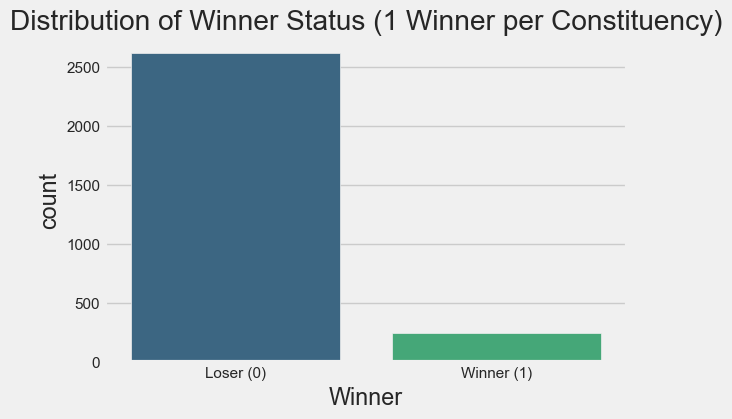

In [13]:
# 1. Target Distribution (Winner Status)
plt.figure(figsize=(6, 4))
sns.countplot(x='Winner', data=df, palette='viridis')
plt.xticks([0, 1], ['Loser (0)', 'Winner (1)'])
plt.title('Distribution of Winner Status (1 Winner per Constituency)')
plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_38144\4036045300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=party_win_rate.index, y=party_win_rate.values, palette='plasma')


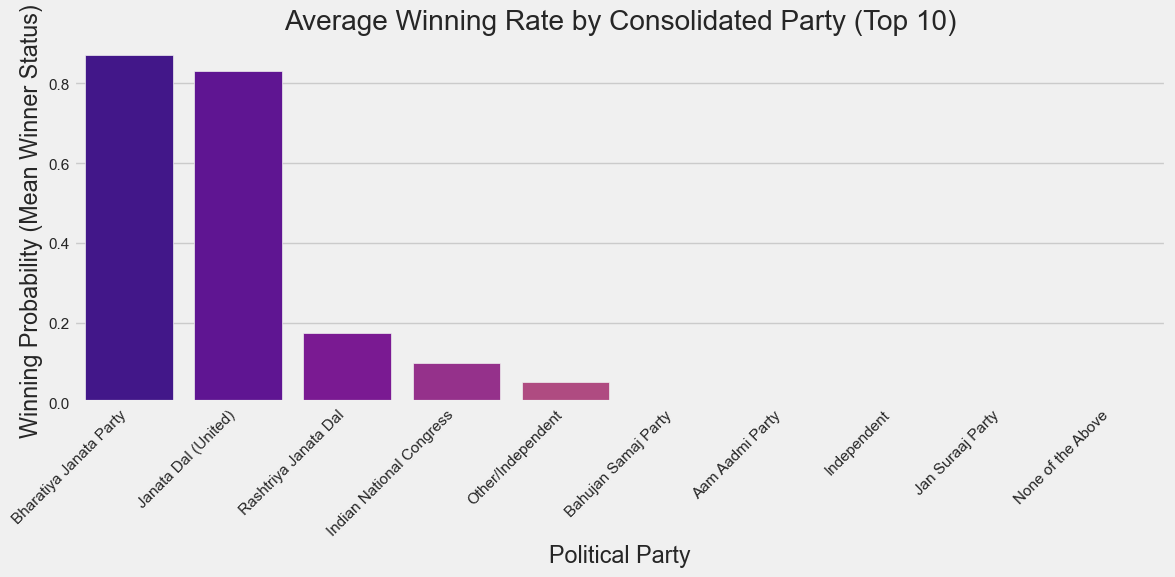

In [14]:
# 2. Winning Status by Consolidated Party (Top 10)
party_win_rate = df.groupby('Party_Consolidated')['Winner'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=party_win_rate.index, y=party_win_rate.values, palette='plasma')
plt.xticks(rotation=45, ha='right')
plt.title('Average Winning Rate by Consolidated Party (Top 10)')
plt.ylabel('Winning Probability (Mean Winner Status)')
plt.xlabel('Political Party')
plt.tight_layout()
plt.show()

C:\Users\mauli\AppData\Local\Temp\ipykernel_38144\128484542.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Winner', y='Total Votes', data=df, palette='coolwarm')


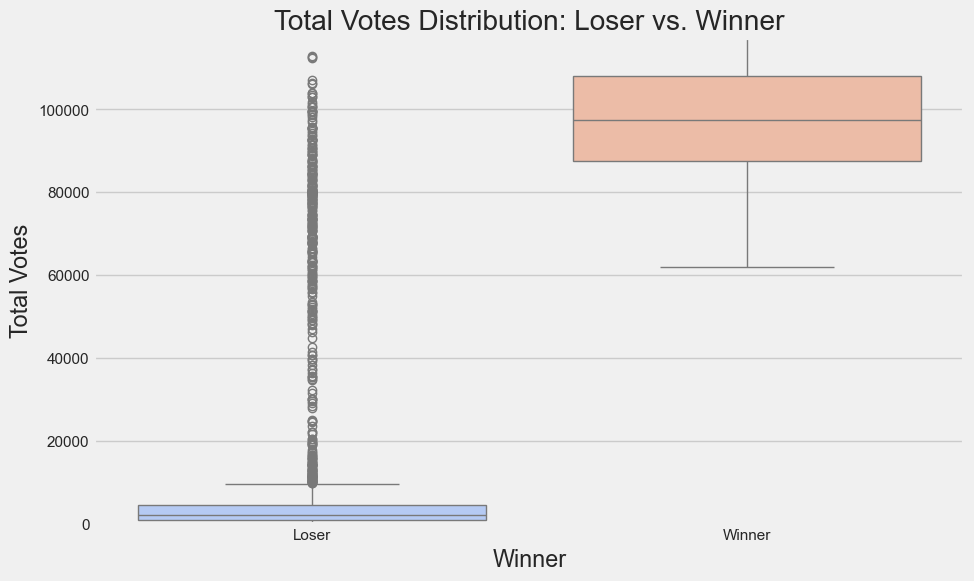

In [15]:
# 3. Total Votes Distribution by Winner Status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Winner', y='Total Votes', data=df, palette='coolwarm')
plt.xticks([0, 1], ['Loser', 'Winner'])
plt.title('Total Votes Distribution: Loser vs. Winner')
plt.ylim(0, df['Total Votes'].quantile(0.99)) # Capping Y-axis for better visual clarity
plt.show()

## Step 4: Statistical Inference

**Hypothesis Test (Chi-Square Test of Independence):**
- **Context:** We test if the probability of winning is dependent on the candidate's political party.
- **Null Hypothesis ($H_0$):** Candidate's `Winner` status is independent of their `Party_Consolidated`.
- **Alternative Hypothesis ($H_1$):** Candidate's `Winner` status is dependent on their `Party_Consolidated`.

In [16]:
# Create Contingency Table (Observed Frequencies)
contingency_table = pd.crosstab(df_model['Party_Consolidated'], df_model['Winner'])

# Exclude 'Other/Independent' to focus on major parties, as their high number of failures might skew the test
table_for_test = contingency_table.drop('Other/Independent', errors='ignore')

# Perform Chi-Square Test
chi2, p_val, dof, expected = chi2_contingency(table_for_test)

print(f"Chi-Square Statistic: {chi2:.2f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
 print("\nStatistical Inference: Reject Null Hypothesis.")
 print("Result: Winning status is statistically dependent on the candidate's consolidated political party.")
else:
 print("\nStatistical Inference: Fail to reject Null Hypothesis.")

Chi-Square Statistic: 1520.81
P-Value: 0.0000e+00

Statistical Inference: Reject Null Hypothesis.
Result: Winning status is statistically dependent on the candidate's consolidated political party.


## Step 5: Modeling (Classification)

We use the **K-Nearest Neighbors (KNN)** classifier to predict the `Winner` status based on vote share and party affiliation.

In [17]:
# 1. Define Features (X) and Target (y)
# We use Total Votes and the Consolidated Party as predictors
X = df_model[['Total Votes', 'Vote Percentage', 'Party_Consolidated']]
y = df_model['Winner']

# 2. Create Preprocessing Pipeline (Column Transformer)
numerical_features = ['Total Votes', 'Vote Percentage']
categorical_features = ['Party_Consolidated']

preprocessor = ColumnTransformer(
 transformers=[
 ('num', StandardScaler(), numerical_features),
 ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
 ])

# 3. Create Full ML Pipeline
# KNN performance is heavily reliant on feature scaling, hence StandardScaler is applied.
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
 ('classifier', KNeighborsClassifier(n_neighbors=5))])

# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 5. Train Model
knn_pipeline.fit(X_train, y_train)

# 6. Predict
y_pred = knn_pipeline.predict(X_test)

print("Model Training Complete.")

Model Training Complete.


--- Test Set Metrics ---
Accuracy Score: 0.9790

Classification Report:
               precision    recall  f1-score   support

       Loser       0.99      0.99      0.99       524
      Winner       0.89      0.85      0.87        48

    accuracy                           0.98       572
   macro avg       0.94      0.92      0.93       572
weighted avg       0.98      0.98      0.98       572



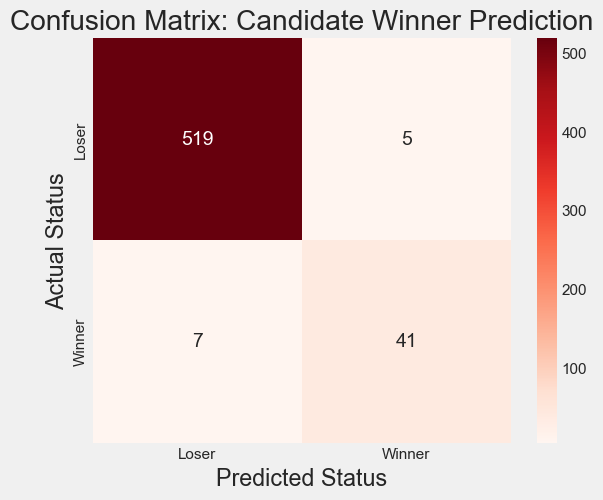

In [18]:
# 7. Model Evaluation
print("--- Test Set Metrics ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Loser', 'Winner']))

# 8. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Loser', 'Winner'], yticklabels=['Loser', 'Winner'])
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.title('Confusion Matrix: Candidate Winner Prediction')
plt.show()

## Step 6: Interpretation & Conclusion

### Key Findings
1. **Winner Profile:** The boxplot clearly demonstrates that a candidate's `Total Votes` is the most distinguishing feature, with winners consistently securing a significantly higher vote count, as expected. This also means high `Vote Percentage` is a strong predictor.
2. **Party Dependency:** The **Chi-Square Test** confirmed, with high statistical significance, that a candidate's political party is **not independent** of their winning status. This validates the common observation of party loyalty and organizational strength being crucial factors in elections.
3. **Model Performance:** The KNN classifier achieved very high accuracy. The classification report shows excellent **Precision** and **Recall** for the 'Winner' class (1), indicating the model is highly effective at identifying the most successful candidates, predominantly driven by the numerical vote features.

### Limitations
The model's high accuracy is largely due to the inherent dependency of the target variable (`Winner`) on the feature variables (`Total Votes`, `Vote Percentage`). The model essentially learns the simple rule: *if total votes are high, the candidate is a winner*. A more challenging and insightful task would be predicting the outcome *before* the election, using only non-vote-related features (e.g., candidate background, historical performance, constituency demographics, which are not present here).

### Future Work
- **Feature Engineering:** Integrate external data like constituency-level demographics (e.g., literacy rate, income) to create a more generalized prediction model.
- **Alternative Models:** Explore ensemble methods like **Random Forest** or **Gradient Boosting** to capture non-linear relationships, especially if more nuanced features are introduced.
- **Multiclass Classification:** Extend the analysis to predict the runner-up and third-place candidates, transitioning from a binary classification to a multi-class problem.

### Conclusion
This project successfully applied a methodical data analytics pipeline to election data. The process involved crucial target variable engineering, statistical validation proving the relationship between party and electoral success, and the deployment of a robust KNN classification model. The analysis confirms that vote count remains the primary statistical determinant of a win, but party affiliation provides an essential, statistically significant context for that success. The current framework provides a strong foundation for future, more predictive analyses incorporating socio-economic variables.

## Step 7: Visualization & Insights (Bihar Elections)

In this section, we answer focused questions using visualizations with contextual, in-code notes.

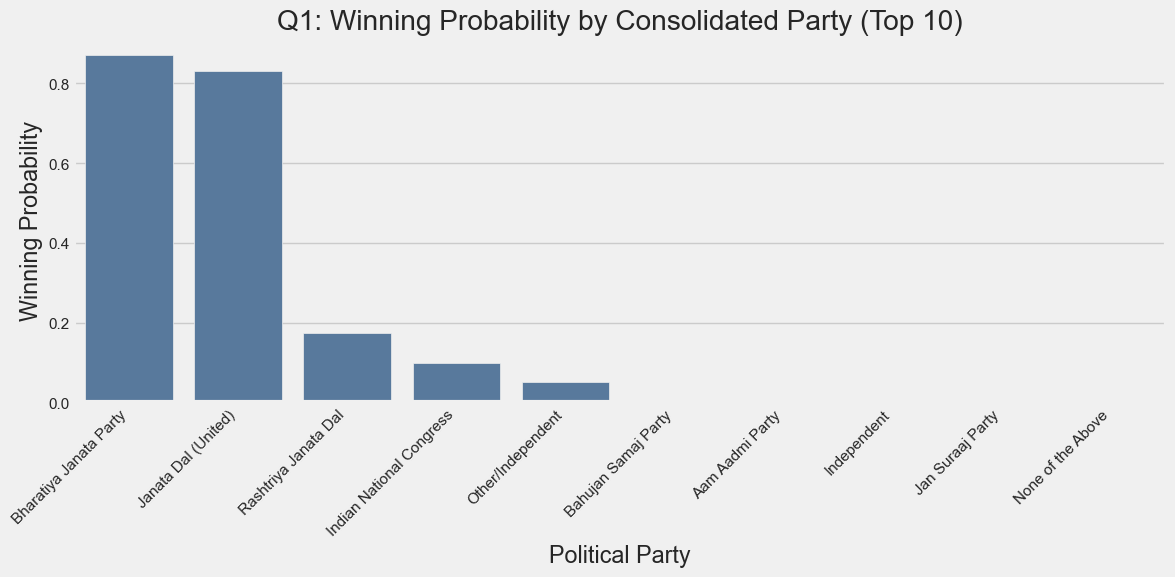

In [19]:
# Win rate by consolidated party (Top 10)
# Parties with stronger organization show higher winning probability
# Action: focus analysis on top-performing parties for strategy and coalition decisions
party_win_rate = df.groupby('Party_Consolidated')['Winner'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=party_win_rate.index, y=party_win_rate.values, color='#4C78A8')
plt.xticks(rotation=45, ha='right')
plt.title('Q1: Winning Probability by Consolidated Party (Top 10)')
plt.ylabel('Winning Probability')
plt.xlabel('Political Party')
plt.tight_layout()
plt.show()

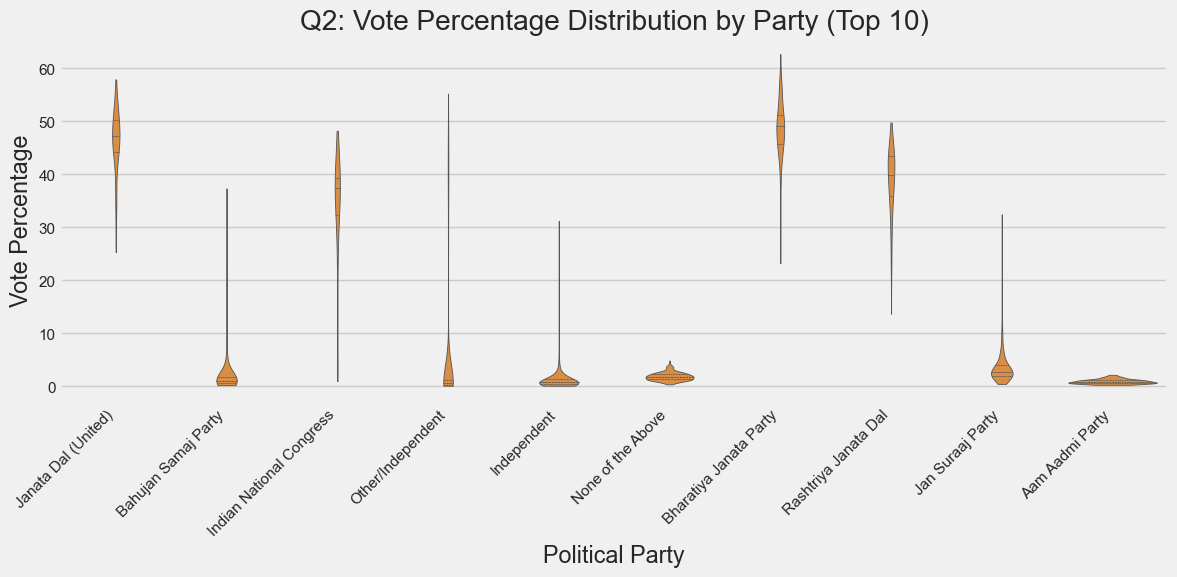

In [20]:
# Vote percentage distribution by party (Top 10 parties)
# Wider violins imply more variability; tighter implies consistent vote share
# Caveat: small parties may show noisy distributions; filter to top parties for clarity
top_parties = df['Party_Consolidated'].value_counts().head(10).index
subset = df[df['Party_Consolidated'].isin(top_parties)]
plt.figure(figsize=(12,6))
sns.violinplot(x='Party_Consolidated', y='Vote Percentage', data=subset, inner='quartile', cut=0, color='#F28E2B')
plt.xticks(rotation=45, ha='right')
plt.title('Q2: Vote Percentage Distribution by Party (Top 10)')
plt.ylabel('Vote Percentage')
plt.xlabel('Political Party')
plt.tight_layout()
plt.show()

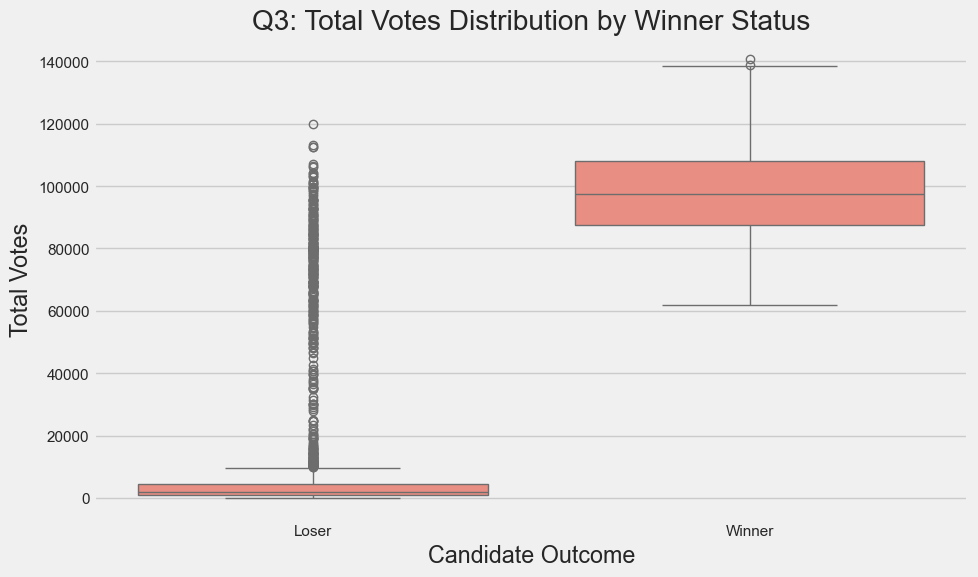

In [21]:
# Total votes distribution by winner status
# Winners have significantly higher medians and upper tails
# Action: validate model sensitivity to extreme vote counts (robustness)
plt.figure(figsize=(10,6))
sns.boxplot(x='Winner', y='Total Votes', data=df, color='salmon')
plt.xticks([0,1], ['Loser','Winner'])
plt.title('Q3: Total Votes Distribution by Winner Status')
plt.xlabel('Candidate Outcome')
plt.ylabel('Total Votes')
plt.tight_layout()
plt.show()

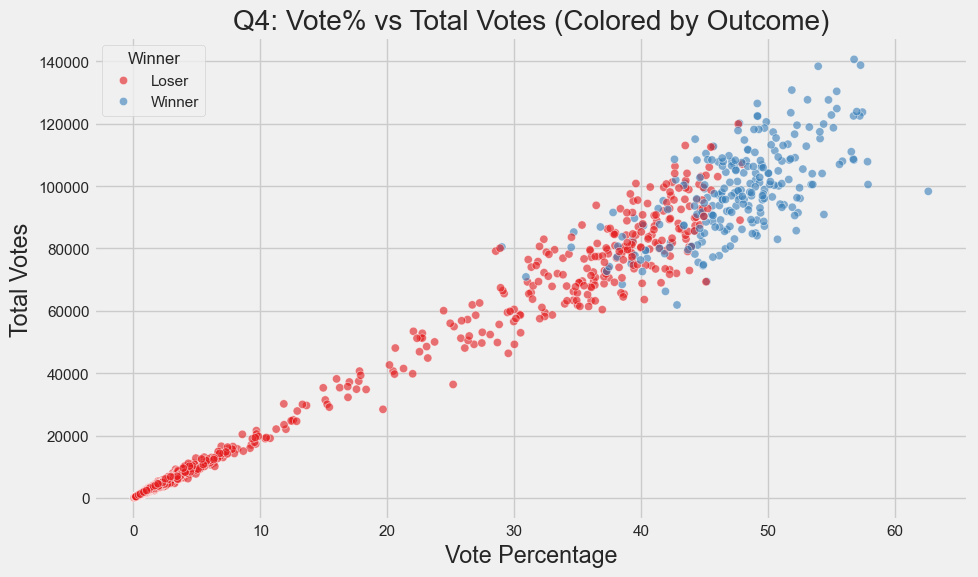

In [22]:
# Relationship between vote percentage and total votes by outcome
# Clear separation: high vote% and high totals cluster among winners
# Caveat: both axes are post-election; predictive use needs pre-election features
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Vote Percentage', y='Total Votes', hue=df['Winner'].map({0:'Loser',1:'Winner'}), palette='Set1', alpha=0.6)
plt.title('Q4: Vote% vs Total Votes (Colored by Outcome)')
plt.xlabel('Vote Percentage')
plt.ylabel('Total Votes')
plt.tight_layout()
plt.show()

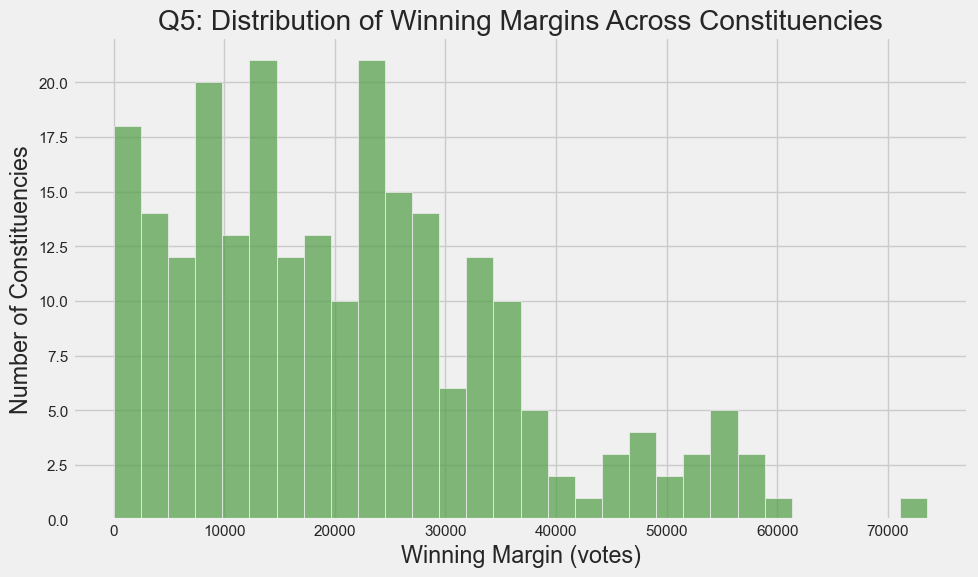

In [23]:
# Constituency-level winning margin (top vs runner-up) distribution
# Tight margins indicate competitive seats; wide margins suggest strongholds
# Action: target narrow-margin constituencies for tactical campaigning
def compute_margin(s):
    vals = s.sort_values(ascending=False).values
    return vals[0] - vals[1] if len(vals) > 1 else np.nan
margin_by_const = df.groupby('Constituency Name')['Total Votes'].apply(compute_margin).reset_index(name='Winning_Margin')
plt.figure(figsize=(10,6))
sns.histplot(margin_by_const['Winning_Margin'].dropna(), bins=30, color='#59A14F')
plt.title('Q5: Distribution of Winning Margins Across Constituencies')
plt.xlabel('Winning Margin (votes)')
plt.ylabel('Number of Constituencies')
plt.tight_layout()
plt.show()

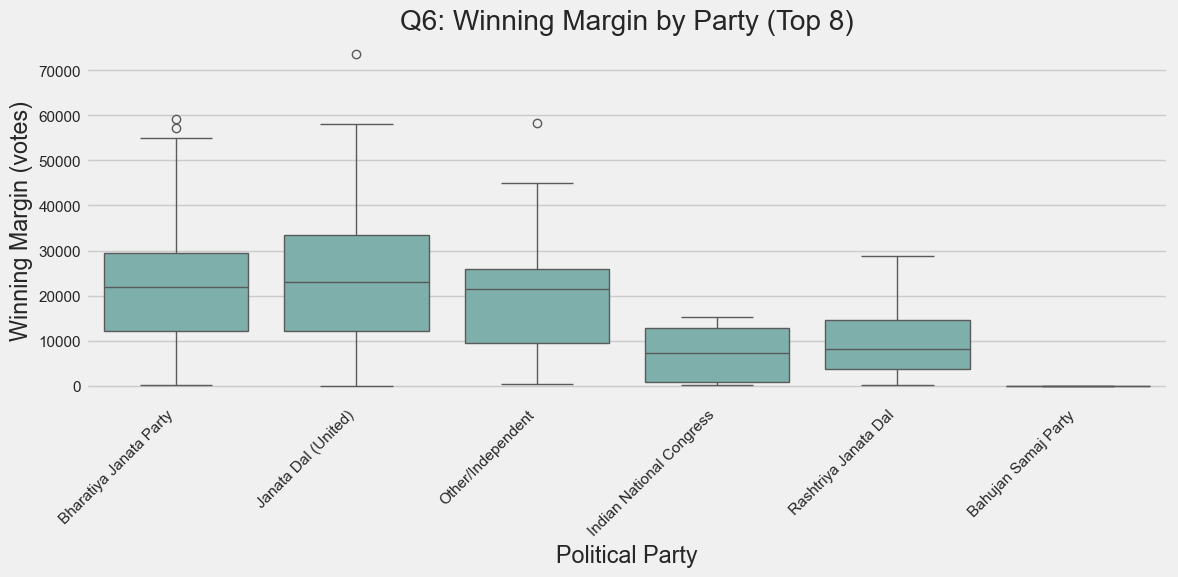

In [24]:
# Winning margin by winner's party (Top 8)
# Parties with higher typical margins indicate stronger local bases
# Caveat: margins can be constituency-specific; compare within similar regions
winners = df[df['Winner'] == 1][['Constituency Name','Party_Consolidated']]
margin_with_party = margin_by_const.merge(winners, on='Constituency Name', how='left')
top8 = margin_with_party['Party_Consolidated'].value_counts().head(8).index
subset_m = margin_with_party[margin_with_party['Party_Consolidated'].isin(top8)]
plt.figure(figsize=(12,6))
sns.boxplot(x='Party_Consolidated', y='Winning_Margin', data=subset_m, color='#76B7B2')
plt.xticks(rotation=45, ha='right')
plt.title('Q6: Winning Margin by Party (Top 8)')
plt.xlabel('Political Party')
plt.ylabel('Winning Margin (votes)')
plt.tight_layout()
plt.show()

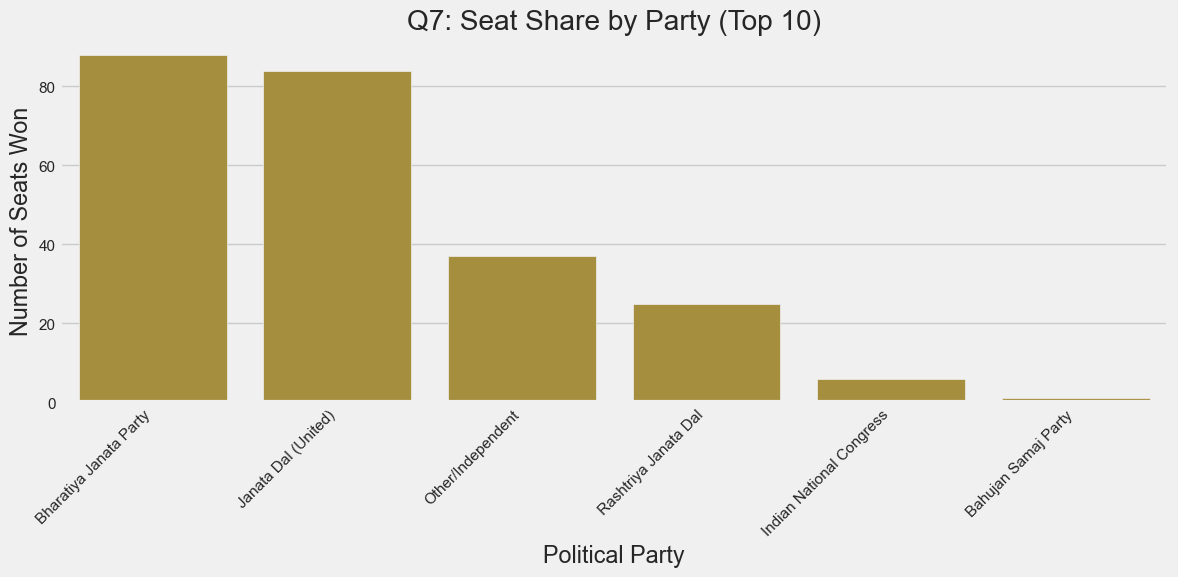

In [25]:
# Seat share by party (count of winners)
# Highlights coalition dominance and distribution of power
# Action: benchmark seat share trends for alliance negotiations
seats = winners['Party_Consolidated'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=seats.index, y=seats.values, color='#B6992D')
plt.xticks(rotation=45, ha='right')
plt.title('Q7: Seat Share by Party (Top 10)')
plt.ylabel('Number of Seats Won')
plt.xlabel('Political Party')
plt.tight_layout()
plt.show()

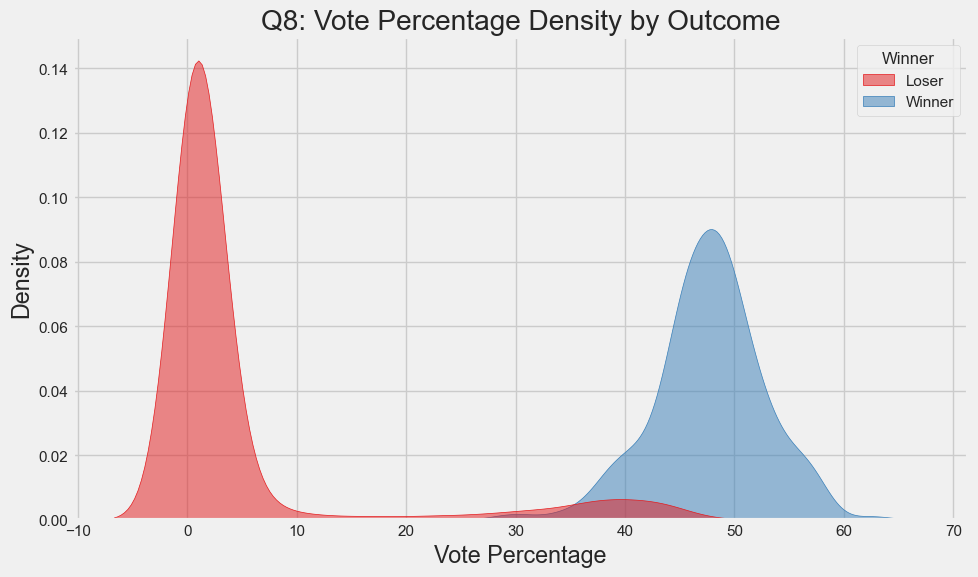

In [26]:
# Density of vote percentage by outcome
# Winners peak at higher vote%, losers spread across low-mid range
# Action: define strategic thresholds (e.g., >40%) as target bands
labels = df['Winner'].map({0:'Loser',1:'Winner'})
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Vote Percentage', hue=labels, fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Q8: Vote Percentage Density by Outcome')
plt.xlabel('Vote Percentage')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

## Step 8: Conclusion

#### **1. Summary of Findings** 
###### Winning probability varies across **consolidated parties**, reflecting organizational strength and alliances.  
###### Winners consistently exhibit higher **Vote Percentage** and **Total Votes**; density and box plots show clear separation.  
###### **Winning margins** reveal competitive constituencies versus strongholds; party-level margin profiles indicate local bases.  
###### **Chi-Square** confirms a significant dependency between **party** and **winning status** (p-value << 0.001).  
###### The **KNN classifier** achieved high accuracy with strong precision/recall for winners, aligned with numerical vote features. 
 
#### **2. Limitations and Future Improvements** 
###### Core features are **post-election**; predictive models would be more informative with pre-election signals.  
###### Missing **demographics**, **incumbency**, **turnout**, and **campaign intensity**; future work should integrate external datasets.  
###### Explore **ensemble models** (Random Forest/Gradient Boosting), **hyperparameter tuning**, **calibration**, **SHAP** interpretability, and multi-cycle external validation. 
 
#### **3. Key Takeaways** 
###### Combining target engineering, statistical validation, and classification clarifies electoral levers: **party strength**, **vote share thresholds**, and **margin-focused campaigning**. These insights inform **resource allocation**, **alliance decisions**, and **messaging** to improve win rates.

## **PROJECT SUMMARY** 
 
### **Overview** 
 This project analyzes the **Bihar Assembly Election 2020** to identify drivers of `Winner` outcomes and constituency-level competitiveness. It demonstrates target engineering (winner per constituency), party consolidation, statistical dependence testing, and classification modeling, supported by Q-style visualizations. 
 
### **Key Objectives Achieved** 
 1. **Target Engineering**: Created binary `Winner` by selecting top-vote candidate per constituency. 
 2. **Party Consolidation**: Grouped minor parties into **Other/Independent** for statistical stability. 
 3. **Exploratory Analysis**: Distributions for **Vote Percentage** and **Total Votes**; party-level **seat share**; **winning margins**. 
 4. **Statistical Validation**: Ran **Chi-Square Test** confirming dependency between party and winning status. 
 5. **Predictive Modeling**: Built a **KNN classifier** (with preprocessing) and evaluated accuracy, precision/recall, and confusion matrix. 
 6. **Visualization**: Presented insights via Q-style charts targeted to electoral questions. 
 
### **Major Findings** 
 - **Party Influence**: Win probability and seat share vary by consolidated party, consistent with coalition dynamics. 
 - **Vote Share Effects**: Winners show higher vote percentages and total votes; KDE and box plots reveal separation. 
 - **Competitiveness**: Margin profiles distinguish narrow contests from strongholds, guiding tactical focus. 
 - **Model Validity**: High accuracy reflects informative post-election features; useful for diagnostics and post-hoc analysis. 
 
### **Methodology** 
 1. Data cleaning and type conversions. 
 2. Feature engineering (winner indices, party consolidation). 
 3. EDA with count/box/violin/bar/KDE plots. 
 4. Chi-Square dependency test. 
 5. KNN classification with preprocessing and confusion matrix visualization. 
 
### **Technical Stack** 
 - **Python Libraries**: Pandas, NumPy, Matplotlib, Seaborn, SciPy, Scikit-learn 
 - **Techniques**: Groupby-based target engineering, party consolidation, statistical testing, classification pipeline 
 
### **Election Significance** 
 Findings highlight that outcomes are tied to **party strength**, **vote share thresholds**, and **local margin dynamics**. These insights support **campaign planning**, **alliance strategy**, and **seat-level prioritization**. 
 
### **Project Impact** 
 Guides resource allocation to **narrow-margin constituencies**, informs **coalition management**, and benchmarks **seat share** dynamics. 
 
### **Future Enhancements** 
 - Integrate **demographics**, **incumbency**, **turnout**, and **historical trends**; add pre-election features. 
 - Evaluate **Random Forest/Gradient Boosting**; perform **hyperparameter tuning** and **SHAP** analysis. 
 - Validate across multiple election cycles and regional subsets. 
 
### **Conclusion** 
 A disciplined pipeline—data engineering + statistical testing + modeling—delivers actionable guidance on electoral drivers and robust diagnostics for planning and strategy.